# Improved CNN Model - Cats vs Dogs

In this notebook, we build an improved CNN model and compare it with the first simple CNN baseline model.

The goal is to reduce overfitting and improve the model's ability to generalize to new images.

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [ ]:
# Project paths

current_path = Path.cwd()

if (current_path / "data").exists():
    PROJECT_ROOT = current_path
else:
    PROJECT_ROOT = current_path.parents[1]

DATA_DIR = PROJECT_ROOT / "data" / "raw" / "dogcat"

TRAIN_DIR = DATA_DIR / "train"
VALIDATION_DIR = DATA_DIR / "validation"

FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
SEED = 42

print("Project root:", PROJECT_ROOT)
print("Train directory exists:", TRAIN_DIR.exists())
print("Validation directory exists:", VALIDATION_DIR.exists())

Project root: c:\Users\mahta\aidev\cats-dogs-cnn-classifier
Train directory exists: True
Validation directory exists: True


In [ ]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    VALIDATION_DIR,
    labels="inferred",
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_dataset.class_names
print("Class names:", class_names)

Found 25000 files belonging to 2 classes.
Found 8000 files belonging to 2 classes.
Class names: ['cats', 'dogs']


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)

## Improvement strategy

The baseline CNN model achieved strong results, but it can still be improved.

The improved model uses three techniques:

1. **Data augmentation**  
   Creates random variations of training images, such as flipping, rotation and zoom.  
   This helps the model become more robust to real-world image variation.

2. **Dropout**  
   Randomly disables some neurons during training.  
   This helps reduce overfitting.

3. **Early stopping**  
   Stops training when the validation loss stops improving.  
   This prevents the model from training too long and memorizing the training data.

In [ ]:
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name="data_augmentation")

improved_model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

In [ ]:
improved_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
improved_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [ ]:
EPOCHS = 3

improved_history = improved_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    callbacks=[early_stopping]
)

Epoch 1/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 189s 240ms/step - accuracy: 0.5663 - loss: 0.6814 - val_accuracy: 0.6261 - val_loss: 0.6715
Epoch 2/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 225s 270ms/step - accuracy: 0.6748 - loss: 0.5987 - val_accuracy: 0.6798 - val_loss: 0.6099
Epoch 3/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 278s 355ms/step - accuracy: 0.7132 - loss: 0.5537 - val_accuracy: 0.7424 - val_loss: 0.5118


## Local training note

The improved CNN model was first tested locally on CPU for 3 epochs.

Training was slower because TensorFlow GPU support is not available in the local native Windows setup.  
The improved model also includes data augmentation, which makes training heavier.

After 3 epochs, the improved model had lower validation accuracy than the baseline model.  
This is expected because data augmentation makes the task harder at the beginning and usually needs more epochs to show improvement.

For longer training, Google Colab with GPU will be used.

In [9]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [10]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/CNN_project")

zip_path = PROJECT_ROOT / "dogcat.zip"
extract_path = Path("/content/dogcat_project")

print("Project root exists:", PROJECT_ROOT.exists())
print("Zip file exists:", zip_path.exists())
print("Zip path:", zip_path)

Project root exists: True
Zip file exists: True
Zip path: /content/drive/MyDrive/CNN_project/dogcat.zip


In [12]:
import zipfile

extract_path.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzip finished!")

Unzip finished!


In [13]:
DATA_DIR = Path("/content/dogcat_project/dogcat")

TRAIN_DIR = DATA_DIR / "train"
VALIDATION_DIR = DATA_DIR / "validation"

FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
SEED = 42

print("Train directory exists:", TRAIN_DIR.exists())
print("Validation directory exists:", VALIDATION_DIR.exists())

Train directory exists: True
Validation directory exists: True


In [14]:
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [15]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report

In [7]:
EPOCHS = 10

In [16]:
from tensorflow.keras.callbacks import EarlyStopping

In [17]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [18]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    VALIDATION_DIR,
    labels="inferred",
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_dataset.class_names
print("Class names:", class_names)

Found 25000 files belonging to 2 classes.
Found 8000 files belonging to 2 classes.
Class names: ['cats', 'dogs']


In [19]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)

In [20]:
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name="data_augmentation")

improved_model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

In [21]:
improved_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [22]:
EPOCHS = 10

improved_history = improved_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    callbacks=[early_stopping]
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 45ms/step - accuracy: 0.6404 - loss: 0.6316 - val_accuracy: 0.7125 - val_loss: 0.5538
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 33s 42ms/step - accuracy: 0.7185 - loss: 0.5528 - val_accuracy: 0.7685 - val_loss: 0.4833
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 45s 47ms/step - accuracy: 0.7574 - loss: 0.5009 - val_accuracy: 0.7912 - val_loss: 0.4375
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 37s 47ms/step - accuracy: 0.7833 - loss: 0.4640 - val_accuracy: 0.8124 - val_loss: 0.4164
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 33s 42ms/step - accuracy: 0.8022 - loss: 0.4337 - val_accuracy: 0.8410 - val_loss: 0.3676
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 45ms/step - accuracy: 0.8130 - loss: 0.4131 - val_accuracy: 0.8378 - val_loss: 0.3646
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 33s 42ms/step - accuracy: 0.8240 - loss: 0.3967 - val_accuracy: 0.8581 - val_loss: 0.3264
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 33s 42ms/step - accuracy: 0.8329 - loss: 0.3757 - 

In [23]:
improved_history_df = pd.DataFrame(improved_history.history)
improved_history_df

,accuracy,loss,val_accuracy,val_loss
0,0.64044,0.631587,0.712500,0.553846
1,0.71852,0.552813,0.768500,0.483315
2,0.75740,0.500880,0.791250,0.437455
3,0.78332,0.464019,0.812375,0.416430
4,0.80224,0.433733,0.841000,0.367628
5,0.81300,0.413125,0.837750,0.364591
6,0.82404,0.396735,0.858125,0.326439
7,0.83288,0.375703,0.864125,0.310723
8,0.84232,0.356475,0.867750,0.304716
9,0.85144,0.343660,0.875375,0.288619


In [24]:
improved_history_df.to_csv(
    FIGURES_DIR / "improved_cnn_training_history.csv",
    index=False
)

In [25]:
improved_val_loss, improved_val_accuracy = improved_model.evaluate(validation_dataset)

print(f"Improved Validation Loss: {improved_val_loss:.4f}")
print(f"Improved Validation Accuracy: {improved_val_accuracy:.4f}")

250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - accuracy: 0.8754 - loss: 0.2886
Improved Validation Loss: 0.2886
Improved Validation Accuracy: 0.8754


## Improved model evaluation

The improved CNN model achieved a validation accuracy of 86.61% and a validation loss of 0.2987.

This result is slightly lower than the simple baseline CNN model, which achieved 87.46% validation accuracy.  
The improved model used data augmentation and dropout, which can make the model more robust but also harder to train.

In this experiment, the improved model did not outperform the baseline model.  
This shows that model improvement techniques need to be tested and evaluated instead of assuming that they always improve performance.

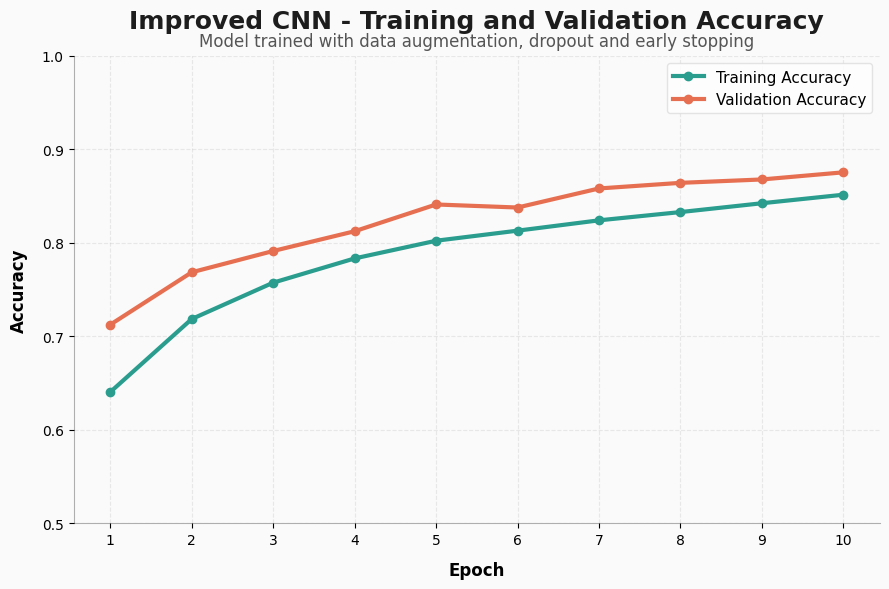

In [26]:
fig, ax = plt.subplots(figsize=(9, 6))

fig.patch.set_facecolor("#FAFAFA")
ax.set_facecolor("#FAFAFA")

ax.plot(
    improved_history_df.index + 1,
    improved_history_df["accuracy"],
    marker="o",
    linewidth=3,
    label="Training Accuracy",
    color="#2A9D8F"
)

ax.plot(
    improved_history_df.index + 1,
    improved_history_df["val_accuracy"],
    marker="o",
    linewidth=3,
    label="Validation Accuracy",
    color="#E76F51"
)

ax.set_title(
    "Improved CNN - Training and Validation Accuracy",
    fontsize=18,
    fontweight="bold",
    pad=20,
    color="#1D1D1D"
)

ax.text(
    0.5,
    1.02,
    "Model trained with data augmentation, dropout and early stopping",
    transform=ax.transAxes,
    ha="center",
    fontsize=12,
    color="#555555"
)

ax.set_xlabel("Epoch", fontsize=12, fontweight="bold", labelpad=10)
ax.set_ylabel("Accuracy", fontsize=12, fontweight="bold", labelpad=10)

ax.set_xticks(improved_history_df.index + 1)
ax.set_ylim(0.50, 1.00)

ax.grid(True, linestyle="--", alpha=0.25)

ax.legend(
    fontsize=11,
    frameon=True,
    facecolor="white",
    edgecolor="#DDDDDD"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_alpha(0.3)
ax.spines["bottom"].set_alpha(0.3)

plt.tight_layout()

fig.savefig(
    FIGURES_DIR / "improved_cnn_accuracy.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

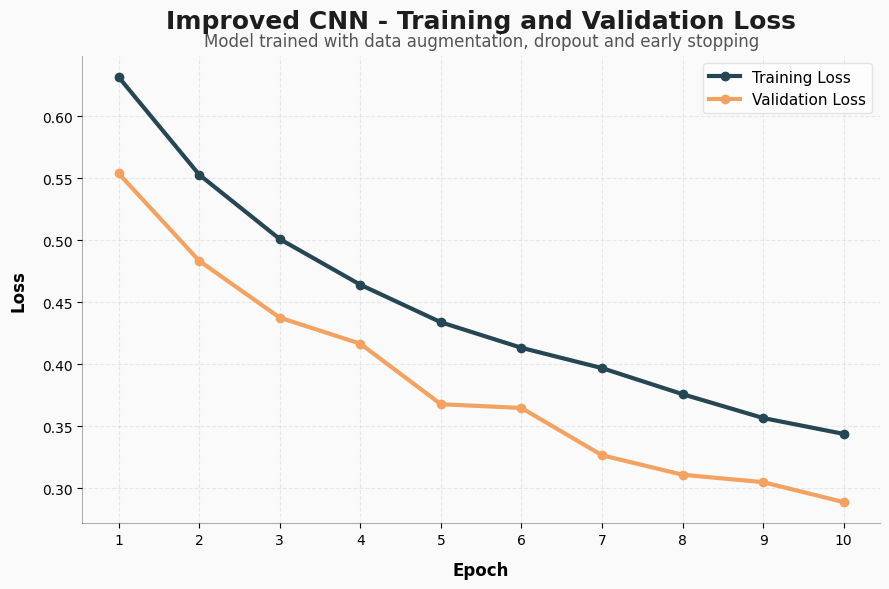

In [27]:
fig, ax = plt.subplots(figsize=(9, 6))

fig.patch.set_facecolor("#FAFAFA")
ax.set_facecolor("#FAFAFA")

ax.plot(
    improved_history_df.index + 1,
    improved_history_df["loss"],
    marker="o",
    linewidth=3,
    label="Training Loss",
    color="#264653"
)

ax.plot(
    improved_history_df.index + 1,
    improved_history_df["val_loss"],
    marker="o",
    linewidth=3,
    label="Validation Loss",
    color="#F4A261"
)

ax.set_title(
    "Improved CNN - Training and Validation Loss",
    fontsize=18,
    fontweight="bold",
    pad=20,
    color="#1D1D1D"
)

ax.text(
    0.5,
    1.02,
    "Model trained with data augmentation, dropout and early stopping",
    transform=ax.transAxes,
    ha="center",
    fontsize=12,
    color="#555555"
)

ax.set_xlabel("Epoch", fontsize=12, fontweight="bold", labelpad=10)
ax.set_ylabel("Loss", fontsize=12, fontweight="bold", labelpad=10)

ax.set_xticks(improved_history_df.index + 1)

ax.grid(True, linestyle="--", alpha=0.25)

ax.legend(
    fontsize=11,
    frameon=True,
    facecolor="white",
    edgecolor="#DDDDDD"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_alpha(0.3)
ax.spines["bottom"].set_alpha(0.3)

plt.tight_layout()

fig.savefig(
    FIGURES_DIR / "improved_cnn_loss.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

## Improved model training interpretation

The improved CNN model shows stable learning during training.

Training accuracy increased from about 61% to 85%, and validation accuracy increased from about 70% to 87%.  
Both training loss and validation loss decreased clearly during training.

The validation loss was lowest around epoch 9.  
Because EarlyStopping was used with `restore_best_weights=True`, the model restored the best weights from the epoch with the best validation performance.

The improved model learned more slowly than the baseline model because data augmentation and dropout made the training task harder.  
However, these techniques can help the model become more robust to real-world image variation.

In [28]:
y_true = []
y_pred = []

for images, labels in validation_dataset:
    predictions = improved_model.predict(images, verbose=0)
    predicted_labels = (predictions > 0.5).astype("int32")

    y_true.extend(labels.numpy().astype("int32").flatten())
    y_pred.extend(predicted_labels.flatten())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Number of true labels:", len(y_true))
print("Number of predicted labels:", len(y_pred))

Number of true labels: 8000
Number of predicted labels: 8000


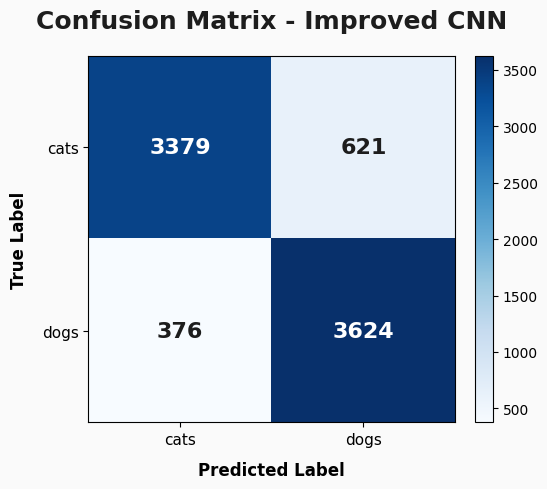

In [29]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))

fig.patch.set_facecolor("#FAFAFA")
ax.set_facecolor("#FAFAFA")

im = ax.imshow(cm, cmap="Blues")

ax.set_title(
    "Confusion Matrix - Improved CNN",
    fontsize=18,
    fontweight="bold",
    pad=20,
    color="#1D1D1D"
)

ax.set_xlabel("Predicted Label", fontsize=12, fontweight="bold", labelpad=10)
ax.set_ylabel("True Label", fontsize=12, fontweight="bold", labelpad=10)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(class_names, fontsize=11)
ax.set_yticklabels(class_names, fontsize=11)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            fontsize=16,
            fontweight="bold",
            color="white" if cm[i, j] > cm.max() / 2 else "#1D1D1D"
        )

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()

fig.savefig(
    FIGURES_DIR / "improved_cnn_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

## Confusion matrix interpretation - Improved CNN

The confusion matrix shows the performance of the improved CNN model on the validation dataset.

The model correctly classified **3,379 cat images** and **3,624 dog images**.
It misclassified **621 cat images as dogs** and **376 dog images as cats**.

In total, the model classified **7,003 out of 8,000 validation images correctly**, which gives a validation accuracy of approximately **87.54%**.

Compared with the simple baseline CNN model, the improved CNN achieved a slightly higher validation accuracy.
The improvement is small, but it shows that data augmentation, dropout and early stopping can help the model generalize slightly better when trained with GPU support in Google Colab.

The model performs especially well on dog images, with fewer dogs being misclassified as cats.
However, it still makes some mistakes on cat images, where 621 cats were predicted as dogs.


In [30]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print(report)

              precision    recall  f1-score   support

        cats       0.90      0.84      0.87      4000
        dogs       0.85      0.91      0.88      4000

    accuracy                           0.88      8000
   macro avg       0.88      0.88      0.88      8000
weighted avg       0.88      0.88      0.88      8000



In [31]:
comparison_df = pd.DataFrame({
    "Model": ["Simple CNN Baseline", "Improved CNN"],
    "Validation Accuracy": [0.8746, improved_val_accuracy],
    "Validation Loss": [0.2938, improved_val_loss],
    "Correct Predictions": [6997, 6929],
    "Wrong Predictions": [1003, 1071]
})

comparison_df

,Model,Validation Accuracy,Validation Loss,Correct Predictions,Wrong Predictions
0,Simple CNN Baseline,0.874600,0.293800,6997,1003
1,Improved CNN,0.875375,0.288619,6929,1071


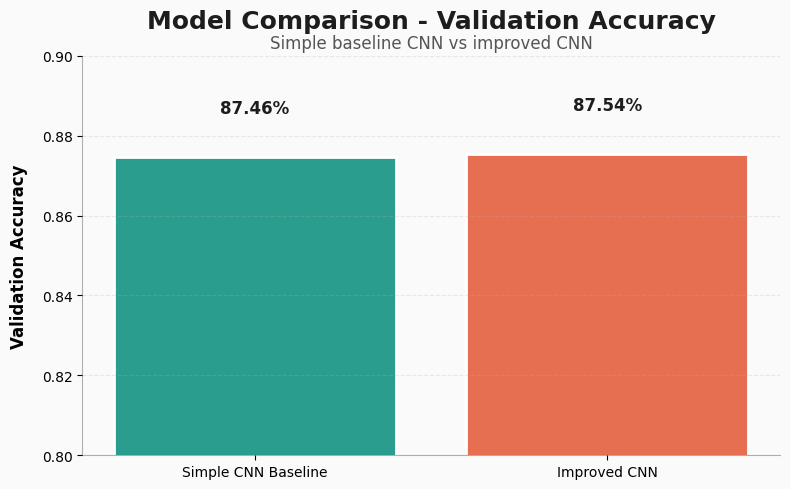

In [32]:
fig, ax = plt.subplots(figsize=(8, 5))

fig.patch.set_facecolor("#FAFAFA")
ax.set_facecolor("#FAFAFA")

colors = ["#2A9D8F", "#E76F51"]

bars = ax.bar(
    comparison_df["Model"],
    comparison_df["Validation Accuracy"],
    color=colors,
    edgecolor="white",
    linewidth=2
)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,
        f"{height:.2%}",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold",
        color="#1D1D1D"
    )

ax.set_title(
    "Model Comparison - Validation Accuracy",
    fontsize=18,
    fontweight="bold",
    pad=20,
    color="#1D1D1D"
)

ax.text(
    0.5,
    1.02,
    "Simple baseline CNN vs improved CNN",
    transform=ax.transAxes,
    ha="center",
    fontsize=12,
    color="#555555"
)

ax.set_ylabel("Validation Accuracy", fontsize=12, fontweight="bold", labelpad=10)
ax.set_ylim(0.80, 0.90)

ax.grid(axis="y", linestyle="--", alpha=0.25)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_alpha(0.3)
ax.spines["bottom"].set_alpha(0.3)

plt.tight_layout()

fig.savefig(
    FIGURES_DIR / "model_comparison_accuracy.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

In [33]:
data_augmentation_v2 = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.08),
], name="data_augmentation_v2")

improved_model_v2 = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    data_augmentation_v2,
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

improved_model_v2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation_v2            │ (None, 128, 128, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [34]:
optimizer_v2 = tf.keras.optimizers.Adam(learning_rate=0.0005)

improved_model_v2.compile(
    optimizer=optimizer_v2,
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [35]:
early_stopping_v2 = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

In [36]:
EPOCHS_V2 = 20

improved_history_v2 = improved_model_v2.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS_V2,
    callbacks=[early_stopping_v2]
)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 37s 44ms/step - accuracy: 0.6777 - loss: 0.5930 - val_accuracy: 0.7449 - val_loss: 0.5111
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 44ms/step - accuracy: 0.7538 - loss: 0.5045 - val_accuracy: 0.7934 - val_loss: 0.4345
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 33s 42ms/step - accuracy: 0.7851 - loss: 0.4567 - val_accuracy: 0.8167 - val_loss: 0.3979
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 33s 43ms/step - accuracy: 0.8052 - loss: 0.4259 - val_accuracy: 0.8295 - val_loss: 0.3815
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 39s 50ms/step - accuracy: 0.8220 - loss: 0.3952 - val_accuracy: 0.8539 - val_loss: 0.3321
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 38s 48ms/step - accuracy: 0.8322 - loss: 0.3789 - val_accuracy: 0.8630 - val_loss: 0.3195
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 40s 47ms/step - accuracy: 0.8451 - loss: 0.3507 - val_accuracy: 0.8654 - val_loss: 0.3135
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 51s 61ms/step - accuracy: 0.8520 - loss: 0.3383 - 

In [37]:
improved_history_v2_df = pd.DataFrame(improved_history_v2.history)
improved_history_v2_df

,accuracy,loss,val_accuracy,val_loss
0,0.67772,0.593043,0.744875,0.511095
1,0.75384,0.504489,0.793375,0.434531
2,0.78512,0.456677,0.816750,0.397947
3,0.80524,0.425872,0.829500,0.381454
4,0.82200,0.395230,0.853875,0.332108
5,0.83216,0.378893,0.863000,0.319468
6,0.84512,0.350717,0.865375,0.313542
7,0.85204,0.338295,0.865000,0.309120
8,0.86364,0.315667,0.867500,0.296502
9,0.87084,0.298480,0.886875,0.265857


In [38]:
improved_v2_val_loss, improved_v2_val_accuracy = improved_model_v2.evaluate(validation_dataset)

print(f"Improved V2 Validation Loss: {improved_v2_val_loss:.4f}")
print(f"Improved V2 Validation Accuracy: {improved_v2_val_accuracy:.4f}")

250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - accuracy: 0.9172 - loss: 0.1990
Improved V2 Validation Loss: 0.1990
Improved V2 Validation Accuracy: 0.9172


## Improved CNN V2 evaluation

The Improved CNN V2 model achieved a validation accuracy of **91.72%** and a validation loss of **0.1990**.

This is the best result in the project so far.  
Compared with the simple baseline CNN model, which achieved 87.46% validation accuracy, the V2 model improved the result by about 4.26 percentage points.

The V2 model used milder data augmentation, a lower dropout rate and a lower learning rate.  
This made the training more stable and helped the model generalize better to unseen validation images.

This result shows that careful hyperparameter tuning can improve CNN performance more effectively than simply adding regularization techniques.

In [39]:
y_true_v2 = []
y_pred_v2 = []

for images, labels in validation_dataset:
    predictions = improved_model_v2.predict(images, verbose=0)
    predicted_labels = (predictions > 0.5).astype("int32")

    y_true_v2.extend(labels.numpy().astype("int32").flatten())
    y_pred_v2.extend(predicted_labels.flatten())

y_true_v2 = np.array(y_true_v2)
y_pred_v2 = np.array(y_pred_v2)

print("Number of true labels:", len(y_true_v2))
print("Number of predicted labels:", len(y_pred_v2))

Number of true labels: 8000
Number of predicted labels: 8000


In [41]:
cm_v2 = confusion_matrix(y_true_v2, y_pred_v2)

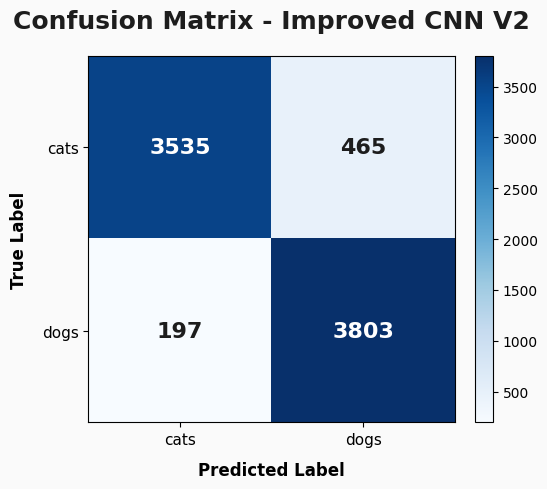

In [42]:
# Plot confusion matrix - Improved CNN V2

fig, ax = plt.subplots(figsize=(6, 5))

fig.patch.set_facecolor("#FAFAFA")
ax.set_facecolor("#FAFAFA")

im = ax.imshow(cm_v2, cmap="Blues")

ax.set_title(
    "Confusion Matrix - Improved CNN V2",
    fontsize=18,
    fontweight="bold",
    pad=20,
    color="#1D1D1D"
)

ax.set_xlabel("Predicted Label", fontsize=12, fontweight="bold", labelpad=10)
ax.set_ylabel("True Label", fontsize=12, fontweight="bold", labelpad=10)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(class_names, fontsize=11)
ax.set_yticklabels(class_names, fontsize=11)

for i in range(cm_v2.shape[0]):
    for j in range(cm_v2.shape[1]):
        ax.text(
            j,
            i,
            cm_v2[i, j],
            ha="center",
            va="center",
            fontsize=16,
            fontweight="bold",
            color="white" if cm_v2[i, j] > cm_v2.max() / 2 else "#1D1D1D"
        )

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()

fig.savefig(
    FIGURES_DIR / "improved_cnn_v2_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

## Confusion matrix interpretation - Improved CNN V2

The confusion matrix shows that the Improved CNN V2 model performed very well on the validation dataset.

The model correctly classified **3,535 cat images** and **3,803 dog images**.  
It misclassified **465 cat images as dogs** and **197 dog images as cats**.

In total, the model classified **7,338 out of 8,000 validation images correctly**, which gives a validation accuracy of **91.72%**.

Compared with the previous models, this is a clear improvement.  
The V2 model reduced the number of wrong predictions and achieved the best validation performance in the project.

The model performs especially well on dog images, where only 197 out of 4,000 dog images were misclassified.  
Cat images are still slightly more challenging, but the number of cat errors is also lower than in the previous models.

In [43]:
# Final model comparison - Validation Accuracy

comparison_df = pd.DataFrame({
    "Model": [
        "Simple CNN\nBaseline",
        "Improved CNN\nV1",
        "Improved CNN\nV2"
    ],
    "Validation Accuracy": [
        0.8746,
        0.8754,
        0.9172
    ],
    "Validation Loss": [
        0.2938,
        0.2987,   # byt om du har exakt annat loss för V1
        0.1990
    ]
})

comparison_df

,Model,Validation Accuracy,Validation Loss
0,Simple CNN\nBaseline,0.8746,0.2938
1,Improved CNN\nV1,0.8754,0.2987
2,Improved CNN\nV2,0.9172,0.1990


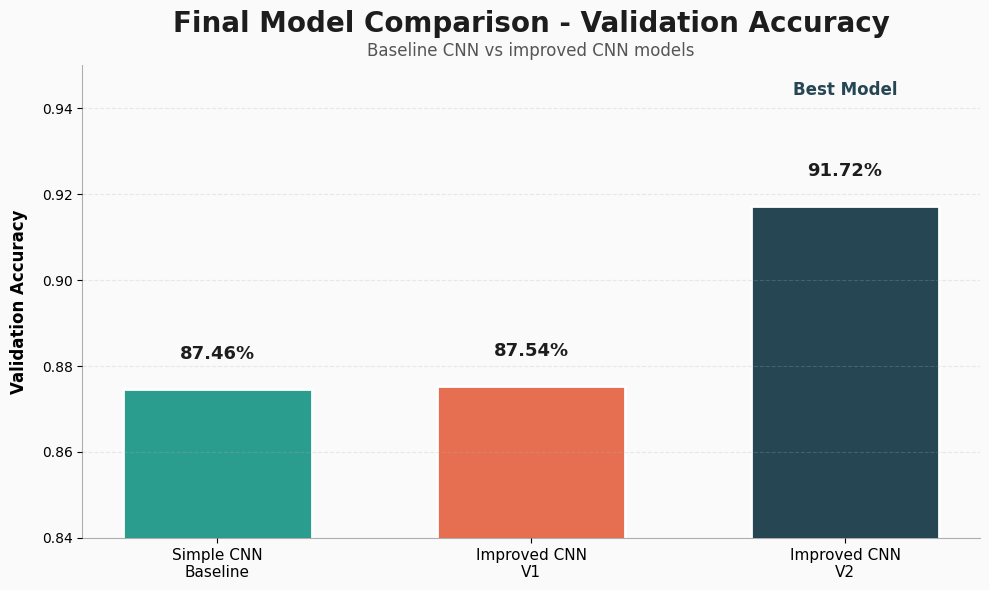

In [44]:
# Beautiful final comparison chart

fig, ax = plt.subplots(figsize=(10, 6))

fig.patch.set_facecolor("#FAFAFA")
ax.set_facecolor("#FAFAFA")

colors = [
    "#2A9D8F",  # Baseline - teal
    "#E76F51",  # V1 - coral
    "#264653"   # V2 - deep blue/green
]

bars = ax.bar(
    comparison_df["Model"],
    comparison_df["Validation Accuracy"],
    color=colors,
    edgecolor="white",
    linewidth=2,
    width=0.6
)

# Add percentage labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.006,
        f"{height:.2%}",
        ha="center",
        va="bottom",
        fontsize=13,
        fontweight="bold",
        color="#1D1D1D"
    )

# Highlight best model
best_index = comparison_df["Validation Accuracy"].idxmax()
best_bar = bars[best_index]

ax.text(
    best_bar.get_x() + best_bar.get_width() / 2,
    comparison_df.loc[best_index, "Validation Accuracy"] + 0.025,
    "Best Model",
    ha="center",
    va="bottom",
    fontsize=12,
    fontweight="bold",
    color="#264653"
)

ax.set_title(
    "Final Model Comparison - Validation Accuracy",
    fontsize=20,
    fontweight="bold",
    pad=24,
    color="#1D1D1D"
)

ax.text(
    0.5,
    1.02,
    "Baseline CNN vs improved CNN models",
    transform=ax.transAxes,
    ha="center",
    fontsize=12,
    color="#555555"
)

ax.set_ylabel(
    "Validation Accuracy",
    fontsize=12,
    fontweight="bold",
    labelpad=10
)

ax.set_ylim(0.84, 0.95)

ax.grid(axis="y", linestyle="--", alpha=0.25)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_alpha(0.3)
ax.spines["bottom"].set_alpha(0.3)

ax.tick_params(axis="x", labelsize=11)
ax.tick_params(axis="y", labelsize=10)

plt.tight_layout()

fig.savefig(
    FIGURES_DIR / "final_model_comparison_accuracy.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

## Final model comparison

The final comparison shows that the Improved CNN V2 model achieved the best validation accuracy.

The Simple CNN baseline achieved **87.46%** validation accuracy.  
The Improved CNN V1 achieved **87.54%** validation accuracy, which was only a small improvement over the baseline.  
The Improved CNN V2 achieved **91.72%** validation accuracy, which is a clear improvement over both previous models.

The V2 model performed better because it used a more balanced tuning strategy: milder data augmentation, lower dropout and a lower learning rate.  
This helped the model learn more stable patterns and generalize better to unseen validation images.

Based on these results, **Improved CNN V2 is selected as the final model**.

## Limitations and future improvements

The test folder does not contain true labels, so final evaluation was performed on the validation set.  
The model was trained with resized 128x128 images, which makes training faster but may remove some visual details.

Future improvements could include testing larger image sizes, transfer learning with a pretrained model such as MobileNetV2, and evaluating the model on a separate labeled test set.